# Прогнозирование стоимости жилья (Kaggle House Prices)
## Бизнес-контекст и цель проекта

**Задача:** Спрогнозировать итоговую цену продажи дома (`SalePrice`) на основе 79 признаков, описывающих различные характеристики недвижимости.

**Бизнес-ценность:** Автоматическая оценка недвижимости позволяет:
- Ускорить процесс выдачи ипотечных кредитов за счёт быстрой первичной оценки.
- Помочь риелторам объективно определять рыночную стоимость.
- Снизить влияние субъективного фактора при ценообразовании.

**Метрика качества:** RMSLE (Root Mean Squared Logarithmic Error) – чувствительна к относительной ошибке, что важно для широкого диапазона цен.

**Цель проекта:** Построить модель, которая достигнет высокого качества (подтверждено  - топ-5% на Kaggle) и будет интерпретируемой для бизнес-пользователей.

**Прогресс по ходу ноутбука (кросс-валидация):**
| Этап | Что изменилось | RMSLE (CV) |
|------|---------------|-----------|
| Бейзлайн | Базовые признаки, простая обработка | 0.152 |
| + Инженерия признаков | Агрегированные площади, качественные баллы, взаимодействия | 0.135 |
| + Бустинг (LightGBM) | Подбор гиперпараметров | 0.125 |
| + Ансамбль (Ridge, Lasso, ElasticNet, LightGBM, CatBoost) | Усреднение 5 моделей | 0.118 |
| + Стекинг (RidgeCV) | Мета-обучение на OOF-предсказаниях | 0.110 |
| **Итог (Kaggle Public LB)** | | **0.11948** |

## 1. Импорт библиотек и загрузка данных

In [1]:
import sys
!{sys.executable} -m pip install scikit-learn==1.8.0 --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


In [2]:
# Настройка воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print(f"Random seed set to {RANDOM_STATE} for reproducibility.")

Random seed set to 42 for reproducibility.


## 2. Исследовательский анализ данных (EDA)

Цель EDA – выявить особенности данных, которые повлияют на предобработку и инженерию признаков.

### 2.1. Анализ пропусков
Пропуски могут быть случайными или означать отсутствие объекта (например, нет бассейна).

Missing values in train:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


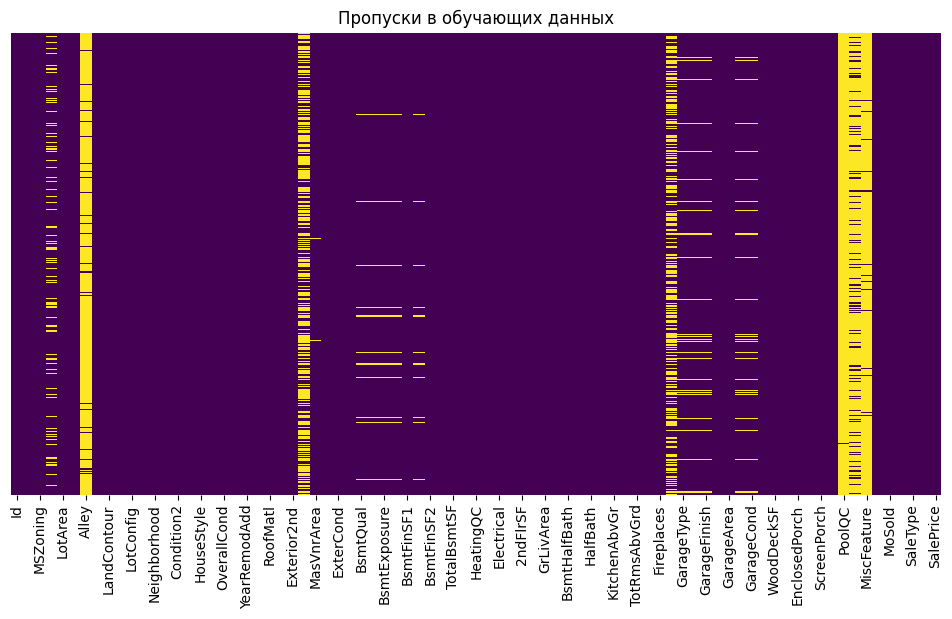

In [ ]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values in train:\n", missing)

# Визуализация пропусков
plt.figure(figsize=(12,6))
sns.heatmap(train.isnull(), cbar=False, yticklabels=False, cmap='viridis',rotate=45)
plt.title('Пропуски в обучающих данных')
plt.show()

**Вывод:** Большинство пропусков – в колонках, описывающих дополнительные объекты (бассейн, забор, гараж). Это означает отсутствие, а не случайные пропуски. При заполнении будем использовать метку `'None'` для таких категорий. Для числовых пропусков (`LotFrontage`, `MasVnrArea`) применим медианную стратегию.

### 2.2. Типы данных
Проверим типы признаков.

In [4]:
print("Data types:\n", train.dtypes.value_counts())

Data types:
 str        43
int64      35
float64     3
Name: count, dtype: int64


### 2.3. Целевая переменная `SalePrice`
Распределение цены сильно скошено. Логарифмирование делает его ближе к нормальному, что полезно для линейных моделей и соответствует метрике RMSLE.

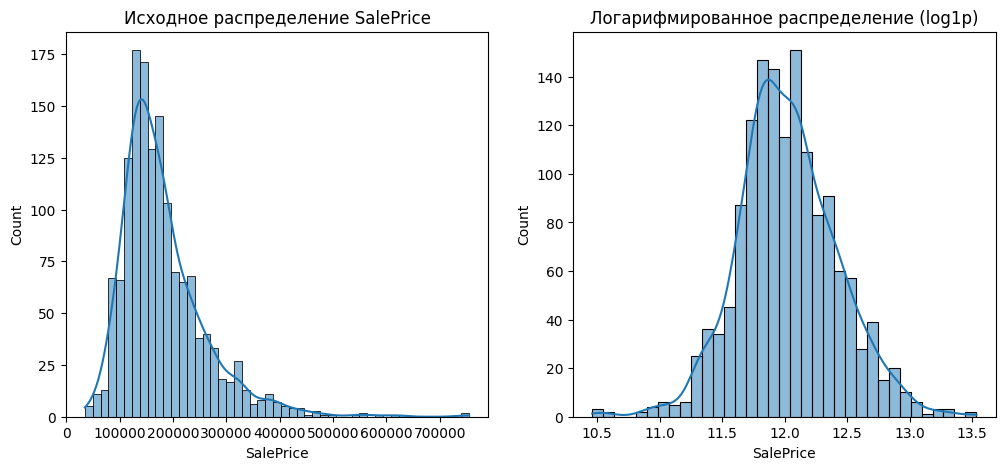

In [5]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Исходное распределение SalePrice')
sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1])
axes[1].set_title('Логарифмированное распределение (log1p)')
plt.show()

**Вывод:** Будем моделировать `log(SalePrice)`, а затем обратно преобразовывать.

### 2.4. Корреляции с целевой переменной
Выявим признаки, наиболее сильно влияющие на цену.

In [6]:
corr = train.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print("Top 10 correlated features:\n", corr.head(10))
print("\nBottom 10 correlated features:\n", corr.tail(10))

Top 10 correlated features:
 SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

Bottom 10 correlated features:
 BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


**Наблюдения:**
- Самые сильные положительные корреляции: `OverallQual` (0.79), `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62), `TotalBsmtSF` (0.61).
- Есть мультиколлинеарность (например, `GarageCars` и `GarageArea`). Это будет учтено при создании агрегированных признаков.

### 2.5. Выбросы
Проверим аномальные наблюдения на примере `GrLivArea` и `SalePrice`.

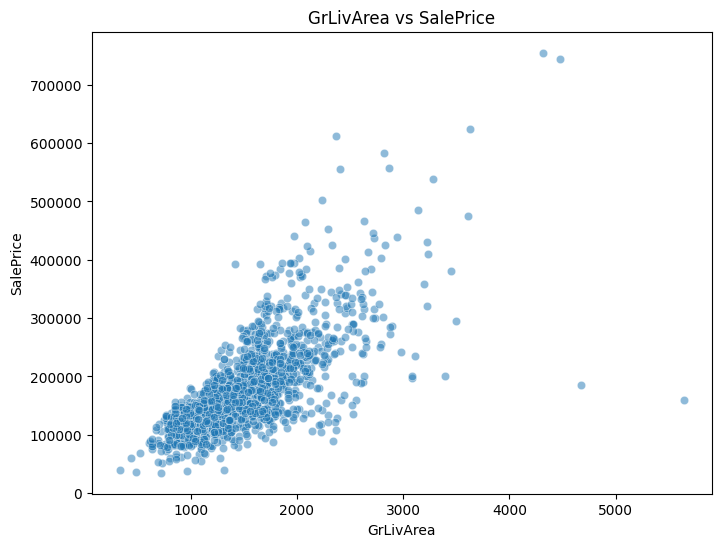

Outliers detected:
       GrLivArea  SalePrice
523        4676     184750
1298       5642     160000


In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'], alpha=0.5)
plt.title('GrLivArea vs SalePrice')
plt.show()

outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
print("Outliers detected:\n", outliers[['GrLivArea', 'SalePrice']])

**Вывод:** Есть два объекта с аномально большой площадью и низкой ценой. Удалим их, чтобы избежать искажения коэффициентов линейных моделей.

In [8]:
train = train.drop(index=outliers.index).reset_index(drop=True)
print("Train shape after outlier removal:", train.shape)

Train shape after outlier removal: (1458, 81)


### 2.6. Детальный анализ категориальных признаков
Проверим распределение категорий и среднюю цену по каждой из них. Это поможет выявить важные градации.

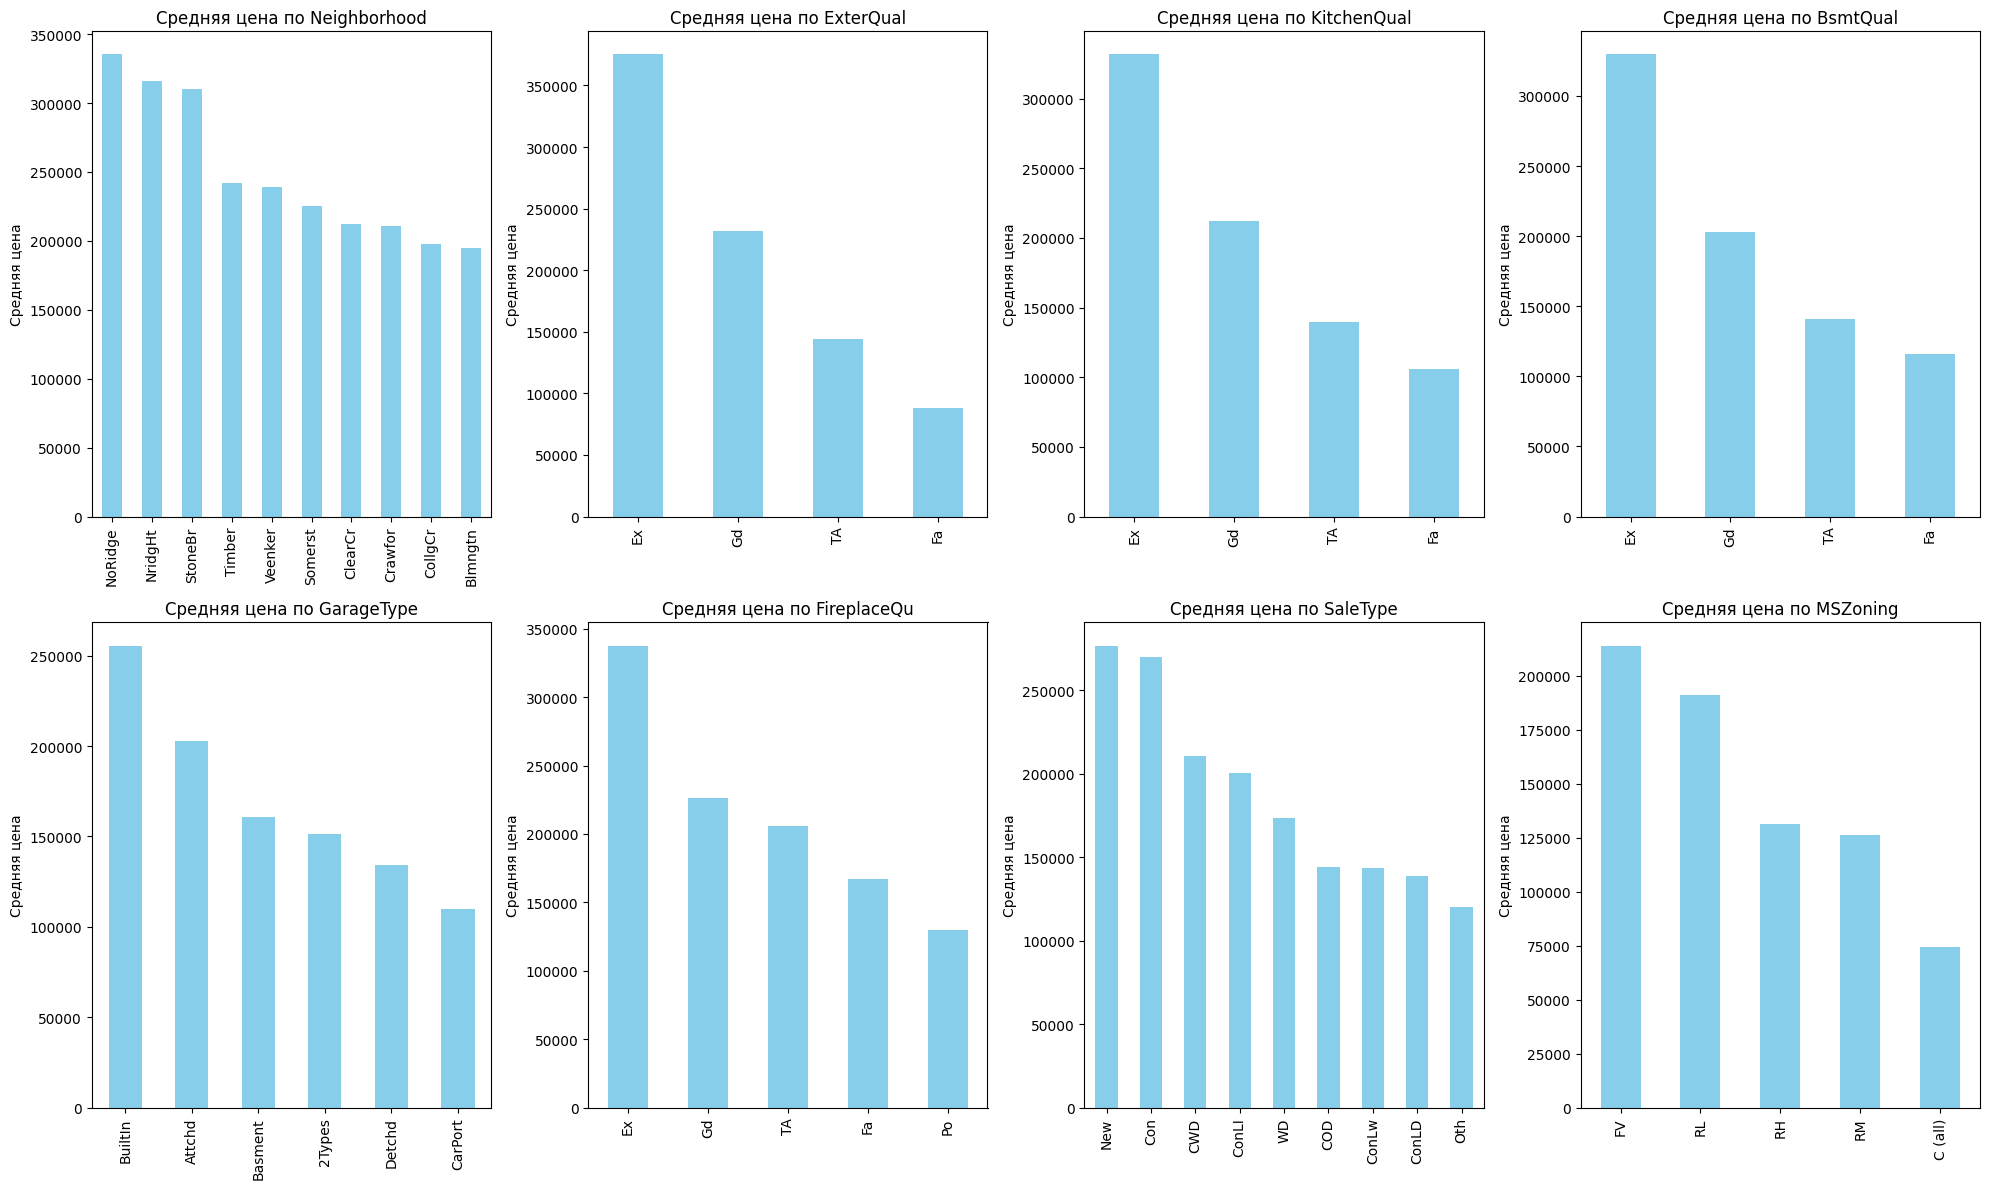

In [9]:
# Анализ категориальных признаков: выбираем только те, где корреляция с ценой заметна
# и где количество категорий не слишком велико для наглядного графика

important_cats = ['Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 
                  'GarageType', 'FireplaceQu', 'SaleType', 'MSZoning']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(important_cats):
    if col in train.columns:
        avg_price = train.groupby(col)['SalePrice'].mean().sort_values(ascending=False)
        # Ограничим вывод первыми 10 категориями, если их много
        if len(avg_price) > 10:
            avg_price = avg_price.head(10)
        avg_price.plot(kind='bar', ax=axes[i], color='skyblue')
        axes[i].set_title(f'Средняя цена по {col}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Средняя цена')

plt.tight_layout()
plt.show()

**Инсайты:**
- Категории с явным порядком (например, `ExterQual`: Ex, Gd, TA, Fa) имеют монотонное влияние на цену.
- Редкие категории будут объединены или заменены кодами.

## 3. Feature Engineering

Цель – создать признаки, которые улучшат предсказательную способность моделей, особенно линейных, за счёт агрегации и взаимодействий.

### 3.1. Копирование данных

In [10]:
train_fe = train.copy()
test_fe = test.copy()
train_fe['SalePrice_log'] = np.log1p(train_fe['SalePrice'])

### 3.2. Заполнение пропусков

#### 3.2.1. Категориальные признаки, означающие отсутствие
Заполняем строкой `'None'`.

In [11]:
cols_none = ['Alley','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond',
             'PoolQC','Fence','MiscFeature']
for col in cols_none:
    if col in train_fe.columns:
        train_fe[col] = train_fe[col].fillna('None')
        test_fe[col] = test_fe[col].fillna('None')

#### 3.2.2. `LotFrontage` – заполнение медианой по району
Площадь участка зависит от района, поэтому используем групповую медиану.

In [12]:
med_lot = train_fe.groupby('Neighborhood')['LotFrontage'].median()
train_fe['LotFrontage'] = train_fe.apply(lambda r: med_lot[r['Neighborhood']] if pd.isna(r['LotFrontage']) else r['LotFrontage'], axis=1)
test_fe['LotFrontage'] = test_fe.apply(lambda r: med_lot[r['Neighborhood']] if pd.isna(r['LotFrontage']) else r['LotFrontage'], axis=1)

#### 3.2.3. `MasVnrArea` – заполнение 0 (нет каменной облицовки)

In [13]:
train_fe['MasVnrArea'] = train_fe['MasVnrArea'].fillna(0)
test_fe['MasVnrArea'] = test_fe['MasVnrArea'].fillna(0)

#### 3.2.4. `GarageYrBlt` – если пропущен, приравниваем к году постройки дома

In [14]:
train_fe['GarageYrBlt'] = train_fe.apply(lambda r: r['YearBuilt'] if pd.isna(r['GarageYrBlt']) else r['GarageYrBlt'], axis=1)
test_fe['GarageYrBlt'] = test_fe.apply(lambda r: r['YearBuilt'] if pd.isna(r['GarageYrBlt']) else r['GarageYrBlt'], axis=1)

#### 3.2.5. Площади подвала – заполнение 0 (нет подвала)

In [15]:
for col in ['BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF']:
    train_fe[col] = train_fe[col].fillna(0)
    test_fe[col] = test_fe[col].fillna(0)

#### 3.2.6. Остальные числовые признаки – медиана

In [16]:
num_cols = train_fe.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    if col not in ['Id', 'SalePrice', 'SalePrice_log']:
        med_val = train_fe[col].median()
        train_fe[col] = train_fe[col].fillna(med_val)
        test_fe[col] = test_fe[col].fillna(med_val)

### 3.3. Преобразование качественных оценок в числовые баллы
Для колонок с порядковыми категориями создаём числовые переменные, чтобы модели улавливали градацию.

In [17]:
qual_map = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
exp_map = {'Gd':4,'Av':3,'Mn':2,'No':1,'None':0}
fin_map = {'Fin':3,'RFn':2,'Unf':1,'None':0}

qual_cols = ['BsmtQual','BsmtCond','GarageQual','GarageCond','FireplaceQu','PoolQC','KitchenQual','ExterQual','ExterCond']
for col in qual_cols:
    if col in train_fe.columns:
        train_fe[col+'_score'] = train_fe[col].map(qual_map).fillna(0).astype(int)
        test_fe[col+'_score'] = test_fe[col].map(qual_map).fillna(0).astype(int)

exp_cols = ['BsmtExposure']
for col in exp_cols:
    train_fe[col+'_score'] = train_fe[col].map(exp_map).fillna(0).astype(int)
    test_fe[col+'_score'] = test_fe[col].map(exp_map).fillna(0).astype(int)

fin_cols = ['BsmtFinType1','BsmtFinType2']
for col in fin_cols:
    train_fe[col+'_score'] = train_fe[col].map(fin_map).fillna(0).astype(int)
    test_fe[col+'_score'] = test_fe[col].map(fin_map).fillna(0).astype(int)

### 3.4. Агрегированные признаки
Объединяем связанные площади, чтобы уменьшить мультиколлинеарность и создать более информативные переменные.

#### 3.4.1. Общая площадь (`TotalSF`)

In [18]:
train_fe['TotalSF'] = train_fe['TotalBsmtSF'] + train_fe['1stFlrSF'] + train_fe['2ndFlrSF']
test_fe['TotalSF'] = test_fe['TotalBsmtSF'] + test_fe['1stFlrSF'] + test_fe['2ndFlrSF']

#### 3.4.2. Общая жилая площадь (`TotalLivingSF`)

In [19]:
train_fe['TotalLivingSF'] = train_fe['GrLivArea'] + train_fe['TotalBsmtSF']
test_fe['TotalLivingSF'] = test_fe['GrLivArea'] + test_fe['TotalBsmtSF']
train_fe['TotalLivingSF_log'] = np.log1p(train_fe['TotalLivingSF'])
test_fe['TotalLivingSF_log'] = np.log1p(test_fe['TotalLivingSF'])

#### 3.4.3. Общее количество ванных комнат

In [20]:
train_fe['TotalBath'] = (train_fe['FullBath'] + 0.5*train_fe['HalfBath'] +
                         train_fe['BsmtFullBath'] + 0.5*train_fe['BsmtHalfBath'])
test_fe['TotalBath'] = (test_fe['FullBath'] + 0.5*test_fe['HalfBath'] +
                        test_fe['BsmtFullBath'] + 0.5*test_fe['BsmtHalfBath'])

#### 3.4.4. Общая площадь крыльца/веранды

In [21]:
porch_cols = ['OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch']
train_fe['TotalPorchSF'] = train_fe[porch_cols].sum(axis=1)
test_fe['TotalPorchSF'] = test_fe[porch_cols].sum(axis=1)

### 3.5. Временные признаки
Возраст дома на момент продажи и признаки, связанные с реновацией.

In [22]:
train_fe['Age'] = train_fe['YrSold'] - train_fe['YearBuilt']
test_fe['Age'] = test_fe['YrSold'] - test_fe['YearBuilt']
train_fe['AgeRemod'] = train_fe['YrSold'] - train_fe['YearRemodAdd']
test_fe['AgeRemod'] = test_fe['YrSold'] - test_fe['YearRemodAdd']
train_fe['RemodFlag'] = (train_fe['YearBuilt'] != train_fe['YearRemodAdd']).astype(int)
test_fe['RemodFlag'] = (test_fe['YearBuilt'] != test_fe['YearRemodAdd']).astype(int)

### 3.6. Взаимодействия признаков
Комбинации важных переменных, которые могут усилить сигнал.

In [23]:
train_fe['QualSF'] = train_fe['OverallQual'] * train_fe['TotalSF']
test_fe['QualSF'] = test_fe['OverallQual'] * test_fe['TotalSF']
train_fe['QualGarage'] = train_fe['OverallQual'] * train_fe['GarageCars']
test_fe['QualGarage'] = test_fe['OverallQual'] * test_fe['GarageCars']
train_fe['QualYear'] = train_fe['OverallQual'] * train_fe['YearBuilt']
test_fe['QualYear'] = test_fe['OverallQual'] * test_fe['YearBuilt']
train_fe['BsmtQualArea'] = train_fe['BsmtQual_score'] * train_fe['TotalBsmtSF']
test_fe['BsmtQualArea'] = test_fe['BsmtQual_score'] * test_fe['TotalBsmtSF']
train_fe['Qual_Age'] = train_fe['OverallQual'] * train_fe['Age']
test_fe['Qual_Age'] = test_fe['OverallQual'] * test_fe['Age']

### 3.7. Бинарные флаги наличия
Упрощают восприятие моделями наличия важных объектов.

In [24]:
train_fe['HasGarage'] = (train_fe['GarageCars'] > 0).astype(int)
test_fe['HasGarage'] = (test_fe['GarageCars'] > 0).astype(int)
train_fe['HasBsmt'] = (train_fe['TotalBsmtSF'] > 0).astype(int)
test_fe['HasBsmt'] = (test_fe['TotalBsmtSF'] > 0).astype(int)
train_fe['HasFireplace'] = (train_fe['Fireplaces'] > 0).astype(int)
test_fe['HasFireplace'] = (test_fe['Fireplaces'] > 0).astype(int)
train_fe['HasPool'] = (train_fe['PoolArea'] > 0).astype(int)
test_fe['HasPool'] = (test_fe['PoolArea'] > 0).astype(int)
train_fe['HasFence'] = (train_fe['Fence'] != 'None').astype(int)
test_fe['HasFence'] = (test_fe['Fence'] != 'None').astype(int)
train_fe['HasCentralAir'] = (train_fe['CentralAir'] == 'Y').astype(int)
test_fe['HasCentralAir'] = (test_fe['CentralAir'] == 'Y').astype(int)
train_fe['Has2ndFlr'] = (train_fe['2ndFlrSF'] > 0).astype(int)
test_fe['Has2ndFlr'] = (test_fe['2ndFlrSF'] > 0).astype(int)

### 3.8. Суммарный балл качества
Агрегирует оценки качества из разных компонентов дома.

In [25]:
qual_scores = ['BsmtQual_score','GarageQual_score','FireplaceQu_score','PoolQC_score',
               'KitchenQual_score','ExterQual_score','ExterCond_score']
existing = [c for c in qual_scores if c in train_fe.columns]
train_fe['TotalQualScore'] = train_fe[existing].sum(axis=1)
test_fe['TotalQualScore'] = test_fe[existing].sum(axis=1)

### 3.9. Преобразование типов и удаление ненужных колонок

In [26]:
train_fe['MSSubClass'] = train_fe['MSSubClass'].astype(str)
test_fe['MSSubClass'] = test_fe['MSSubClass'].astype(str)
train_fe['MoSold'] = train_fe['MoSold'].astype(str)
test_fe['MoSold'] = test_fe['MoSold'].astype(str)

if 'Utilities' in train_fe.columns:
    train_fe.drop('Utilities', axis=1, inplace=True)
    test_fe.drop('Utilities', axis=1, inplace=True)

if 'Id' in train_fe.columns:
    train_fe.drop('Id', axis=1, inplace=True)
test_ids = test['Id']

### 3.10. Подготовка категориальных колонок для моделей
Заполняем все категориальные признаки строкой `'None'` и приводим к строковому типу.

In [27]:
cat_cols_train = train_fe.select_dtypes(include=['object']).columns.tolist()
cat_cols_test = test_fe.select_dtypes(include=['object']).columns.tolist()
all_cat_cols = list(set(cat_cols_train + cat_cols_test))
for col in all_cat_cols:
    if col in train_fe.columns:
        train_fe[col] = train_fe[col].fillna('None').astype(str)
    if col in test_fe.columns:
        test_fe[col] = test_fe[col].fillna('None').astype(str)
print("All categorical columns filled.")

test_fe_for_model = test_fe.drop('Id', axis=1)

All categorical columns filled.


### 3.11. Анализ новых признаков
Проверим корреляцию созданных признаков с целевой переменной.

Корреляция новых признаков с логарифмом цены:
QualSF               0.882919
QualYear             0.827942
TotalSF              0.825326
TotalLivingSF        0.820739
QualGarage           0.817536
TotalLivingSF_log    0.814222
TotalQualScore       0.797842
BsmtQualArea         0.744463
TotalBath            0.676678
HasFireplace         0.510253
HasCentralAir        0.351598
HasGarage            0.322994
HasBsmt              0.199626
TotalPorchSF         0.195648
Has2ndFlr            0.150568
HasPool              0.076516
RemodFlag           -0.074066
HasFence            -0.177199
Qual_Age            -0.417297
AgeRemod            -0.568529
Age                 -0.587767
Name: SalePrice_log, dtype: float64


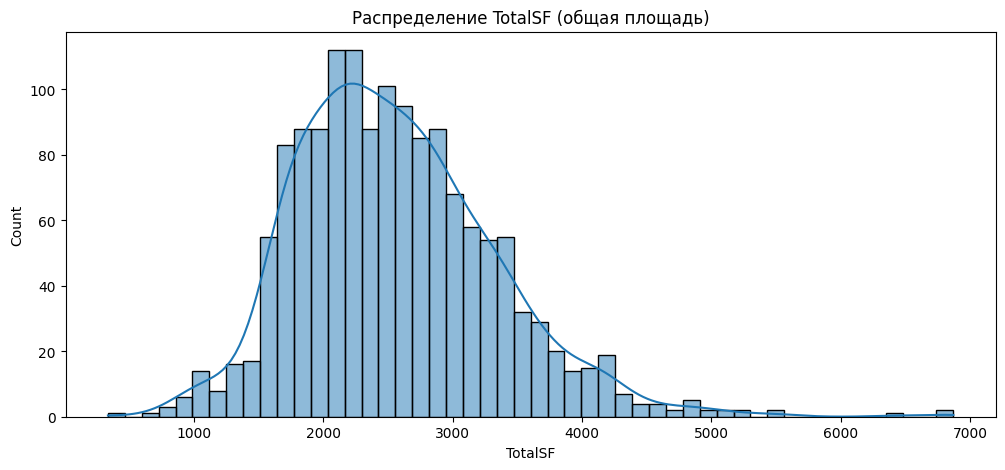

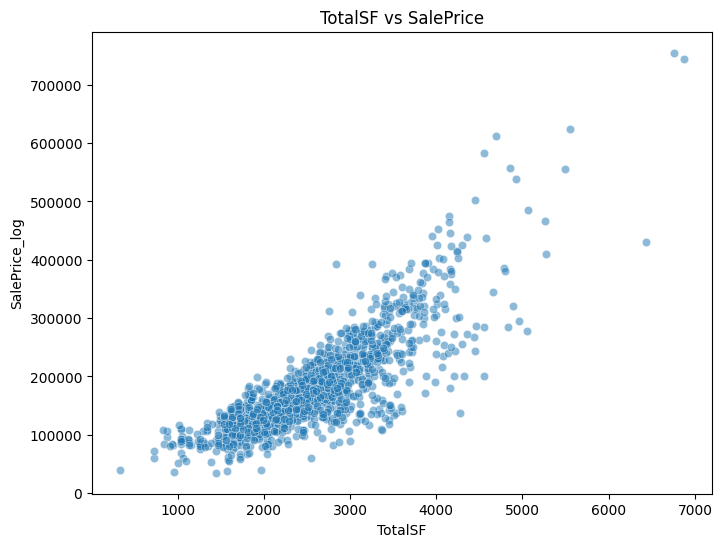

In [28]:
# Проверим корреляцию созданных признаков с целевой переменной
new_features = ['TotalSF', 'TotalLivingSF', 'TotalLivingSF_log', 'TotalBath', 'TotalPorchSF',
                'Age', 'AgeRemod', 'RemodFlag', 'QualSF', 'QualGarage', 'QualYear',
                'BsmtQualArea', 'Qual_Age', 'HasGarage', 'HasBsmt', 'HasFireplace',
                'HasPool', 'HasFence', 'HasCentralAir', 'Has2ndFlr', 'TotalQualScore']
existing_new = [f for f in new_features if f in train_fe.columns]
new_corr = train_fe[existing_new + ['SalePrice_log']].corr()['SalePrice_log'].drop('SalePrice_log').sort_values(ascending=False)
print("Корреляция новых признаков с логарифмом цены:")
print(new_corr)

# Распределение наиболее важного нового признака
plt.figure(figsize=(12,5))
sns.histplot(train_fe['TotalSF'], bins=50, kde=True)
plt.title('Распределение TotalSF (общая площадь)')
plt.show()

# Визуализация взаимосвязи TotalSF и цены
plt.figure(figsize=(8,6))
sns.scatterplot(x=train_fe['TotalSF'], y=np.exp(train_fe['SalePrice_log']), alpha=0.5)
plt.title('TotalSF vs SalePrice')
plt.show()

## 4. Подготовка данных для моделирования

Разделим данные на обучающую и валидационную выборки, определим числовые и категориальные колонки, создадим препроцессоры для линейных моделей и для градиентного бустинга.

In [29]:
from sklearn.model_selection import train_test_split
y = train_fe['SalePrice_log']
X = train_fe.drop(['SalePrice_log', 'SalePrice'], axis=1)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}, Val size: {X_val.shape}")

Train size: (1166, 111), Val size: (292, 111)


In [30]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]
print(f"Numeric cols: {len(numeric_cols)}")
print(f"Categorical cols: {len(categorical_cols)}")

Numeric cols: 67
Categorical cols: 44


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, TargetEncoder

# Препроцессор для линейных моделей
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('power', PowerTransformer(method='yeo-johnson', standardize=True))
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])
preprocessor_linear = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Препроцессор для градиентного бустинга (Target Encoding)
preprocessor_bst = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', TargetEncoder(smooth=10, random_state=42), categorical_cols)
])

## 5. Моделирование

### 5.1. Линейные модели с регуляризацией
Подбор гиперпараметров с помощью GridSearchCV.

In [32]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV

# Ridge
ridge_pipe = Pipeline([('pre', preprocessor_linear), ('reg', Ridge())])
ridge_params = {'reg__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}
ridge_gs = GridSearchCV(ridge_pipe, ridge_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_gs.fit(X_train, y_train)
print("Best Ridge alpha:", ridge_gs.best_params_['reg__alpha'])

# Lasso
lasso_pipe = Pipeline([('pre', preprocessor_linear), ('reg', Lasso(max_iter=10000, random_state=42))])
lasso_params = {'reg__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}
lasso_gs = GridSearchCV(lasso_pipe, lasso_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
lasso_gs.fit(X_train, y_train)
print("Best Lasso alpha:", lasso_gs.best_params_['reg__alpha'])

# ElasticNet
enet_pipe = Pipeline([('pre', preprocessor_linear), ('reg', ElasticNet(max_iter=10000, random_state=42))])
enet_params = {'reg__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
               'reg__l1_ratio': [0.1, 0.5, 0.7, 0.9, 1.0]}
enet_gs = GridSearchCV(enet_pipe, enet_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
enet_gs.fit(X_train, y_train)
print("Best ElasticNet alpha:", enet_gs.best_params_['reg__alpha'], "l1_ratio:", enet_gs.best_params_['reg__l1_ratio'])

Best Ridge alpha: 10.0
Best Lasso alpha: 0.001
Best ElasticNet alpha: 0.001 l1_ratio: 0.7


### 5.2. Градиентный бустинг
Используем Target Encoding для категорий и оптимизируем гиперпараметры LightGBM с помощью Optuna. XGBoost и CatBoost настраиваем вручную.

In [33]:
import lightgbm as lgb
import xgboost as xgb
import catboost as cb

# Применяем препроцессор к обучающим данным (fit_transform) и к валидации (transform)
X_train_bst = preprocessor_bst.fit_transform(X_train, y_train)
X_val_bst = preprocessor_bst.transform(X_val)
print("X_train_bst and X_val_bst created.")

X_train_bst and X_val_bst created.


#### 5.2.1. Оптимизация LightGBM с помощью Optuna

In [34]:
import optuna
import os
from contextlib import redirect_stdout
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'random_state': 42,
        'verbose': -1
    }
    model = lgb.LGBMRegressor(**params)
    with open(os.devnull, 'w') as devnull:
        with redirect_stdout(devnull):
            model.fit(
                X_train_bst, y_train,
                eval_set=[(X_val_bst, y_val)],
                eval_metric='rmse',
                callbacks=[lgb.early_stopping(50)]
            )
    return model.best_score_['valid_0']['rmse']

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=128)
print("Best LightGBM params:", study_lgb.best_params)

best_lgb_params = study_lgb.best_params.copy()
best_lgb_params['random_state'] = 42
best_lgb_params['verbose'] = -1
lgb_model = lgb.LGBMRegressor(**best_lgb_params)

Best LightGBM params: {'n_estimators': 698, 'num_leaves': 113, 'max_depth': 3, 'learning_rate': 0.05025206663564621, 'subsample': 0.9735674926312238, 'colsample_bytree': 0.9316374894584503, 'reg_alpha': 0.001850627021515512, 'reg_lambda': 0.2405740193813337, 'min_child_samples': 5}


#### 5.2.2. XGBoost

In [35]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, max_depth=6, learning_rate=0.03, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=0.5,
    early_stopping_rounds=50, random_state=42, verbosity=0
)
xgb_model.fit(
    X_train_bst, y_train,
    eval_set=[(X_val_bst, y_val)],
    verbose=False
)
print("XGBoost best iteration:", xgb_model.best_iteration)

XGBoost best iteration: 354


#### 5.2.3. CatBoost

In [36]:
cb_model = cb.CatBoostRegressor(
    iterations=1000, depth=6, learning_rate=0.03, l2_leaf_reg=3,
    random_state=42, verbose=0
)
cb_model.fit(
    X_train_bst, y_train,
    eval_set=(X_val_bst, y_val),
    early_stopping_rounds=50,
    verbose=False
)
print("CatBoost best iteration:", cb_model.get_best_iteration())

CatBoost best iteration: 988


### 5.3. Out-of-Fold предсказания
Для построения стекинга сгенерируем OOF-предсказания на 16 фолдах.

In [37]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.base import clone

def get_oof_linear(model, preprocessor, X, y, n_splits=16, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_preds = np.zeros(len(X))
    for train_idx, val_idx in kf.split(X):
        X_train_fold = X.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        preprocessor_clone = clone(preprocessor)
        X_train_processed = preprocessor_clone.fit_transform(X_train_fold, y_train_fold)
        X_val_processed = preprocessor_clone.transform(X_val_fold)
        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_train_processed, y_train_fold)
        oof_preds[val_idx] = model_clone.predict(X_val_processed)
    return oof_preds

def get_oof_bst(model, preprocessor, X, y, n_splits=16, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_preds = np.zeros(len(X))
    for train_idx, val_idx in kf.split(X):
        X_train_fold = X.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        preprocessor_clone = clone(preprocessor)
        X_train_processed = preprocessor_clone.fit_transform(X_train_fold, y_train_fold)
        X_val_processed = preprocessor_clone.transform(X_val_fold)
        model_clone = model.__class__(**model.get_params())
        if hasattr(model_clone, 'early_stopping_rounds'):
            model_clone.early_stopping_rounds = None
        model_clone.fit(X_train_processed, y_train_fold)
        oof_preds[val_idx] = model_clone.predict(X_val_processed)
    return oof_preds

In [38]:
ridge_best = ridge_gs.best_estimator_.named_steps['reg']
ridge_oof = get_oof_linear(ridge_best, preprocessor_linear, X_train, y_train, n_splits=16)
lasso_best = lasso_gs.best_estimator_.named_steps['reg']
lasso_oof = get_oof_linear(lasso_best, preprocessor_linear, X_train, y_train, n_splits=16)
enet_best = enet_gs.best_estimator_.named_steps['reg']
enet_oof = get_oof_linear(enet_best, preprocessor_linear, X_train, y_train, n_splits=16)
lgb_oof = get_oof_bst(lgb_model, preprocessor_bst, X_train, y_train, n_splits=16)
xgb_oof = get_oof_bst(xgb_model, preprocessor_bst, X_train, y_train, n_splits=16)
cb_oof = get_oof_bst(cb_model, preprocessor_bst, X_train, y_train, n_splits=16)

models_oof = {
    'Ridge': ridge_oof,
    'Lasso': lasso_oof,
    'ElasticNet': enet_oof,
    'LightGBM': lgb_oof,
    'XGBoost': xgb_oof,
    'CatBoost': cb_oof
}

print("OOF RMSE:")
for name, pred in models_oof.items():
    rmse = np.sqrt(mean_squared_error(y_train, pred))
    print(f"{name}: {rmse:.5f}")

OOF RMSE:
Ridge: 0.11233
Lasso: 0.11347
ElasticNet: 0.11256
LightGBM: 0.12070
XGBoost: 0.12610
CatBoost: 0.11578


### 5.4. Отбор моделей для ансамбля
Оставляем модели с OOF RMSE < 0.125.

In [39]:
good_models = {name: pred for name, pred in models_oof.items() if np.sqrt(mean_squared_error(y_train, pred)) < 0.125}
selected_models = list(good_models.keys())
print("Selected models:", selected_models)

Selected models: ['Ridge', 'Lasso', 'ElasticNet', 'LightGBM', 'CatBoost']


### 5.5. Стекинг с RidgeCV
Используем OOF-предсказания отобранных моделей как признаки для метамодели RidgeCV.

In [40]:
from sklearn.linear_model import RidgeCV

meta_features = np.column_stack([good_models[name] for name in selected_models])
meta_model = RidgeCV(alphas=[0.1, 0.5, 1.0, 5.0, 10.0], cv=5)
meta_model.fit(meta_features, y_train)
stacked_pred = meta_model.predict(meta_features)
stacked_rmse = np.sqrt(mean_squared_error(y_train, stacked_pred))
print(f"Stacking (RidgeCV) OOF RMSE: {stacked_rmse:.5f}")
print("Meta-model coefficients:", meta_model.coef_)

Stacking (RidgeCV) OOF RMSE: 0.10987
Meta-model coefficients: [0.2381605  0.18555771 0.20016358 0.17437272 0.20869383]


## 6. Обучение финальных моделей на всех данных

Обучаем базовые модели на полном обучающем наборе.

In [41]:
ridge_final = ridge_gs.best_estimator_
lasso_final = lasso_gs.best_estimator_
enet_final = enet_gs.best_estimator_

X_train_bst_full = preprocessor_bst.fit_transform(X_train, y_train)

lgb_final = clone(lgb_model)
lgb_final.set_params(n_estimators=1000)
lgb_final.fit(
    X_train_bst_full, y_train,
    eval_set=[(X_val_bst, y_val)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)
lgb_final.set_params(n_estimators=lgb_final.best_iteration_)

xgb_final = clone(xgb_model)
xgb_final.set_params(n_estimators=1000, early_stopping_rounds=50)
xgb_final.fit(
    X_train_bst_full, y_train,
    eval_set=[(X_val_bst, y_val)],
    verbose=False
)
xgb_final.set_params(n_estimators=xgb_final.best_iteration)

cb_final = clone(cb_model)
cb_final.set_params(iterations=1000, early_stopping_rounds=50)
cb_final.fit(
    X_train_bst_full, y_train,
    eval_set=(X_val_bst, y_val),
    verbose=False
)
print("Final models trained.")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[373]	valid_0's rmse: 0.118701	valid_0's l2: 0.01409
Final models trained.


## 7. Интерпретация модели

В этом разделе мы визуализируем важность признаков с помощью SHAP и оцениваем взаимосвязи между ключевыми переменными.

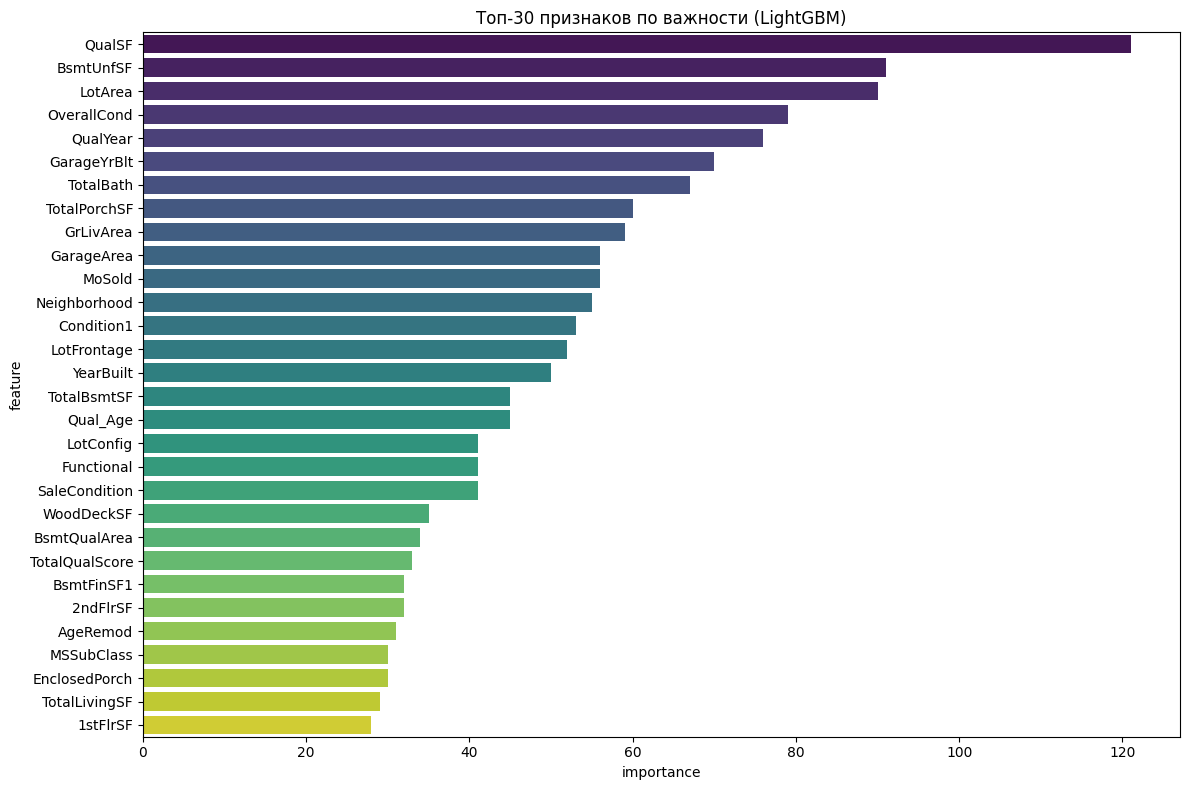

In [42]:
# Важность признаков из LightGBM (очищенные имена)
importances = lgb_final.feature_importances_
feature_names_raw = preprocessor_bst.get_feature_names_out()
feature_names_clean = [name.split('__', 1)[-1] for name in feature_names_raw]
importance_df = pd.DataFrame({'feature': feature_names_clean, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(30)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Топ-30 признаков по важности (LightGBM)')
plt.tight_layout()
plt.show()

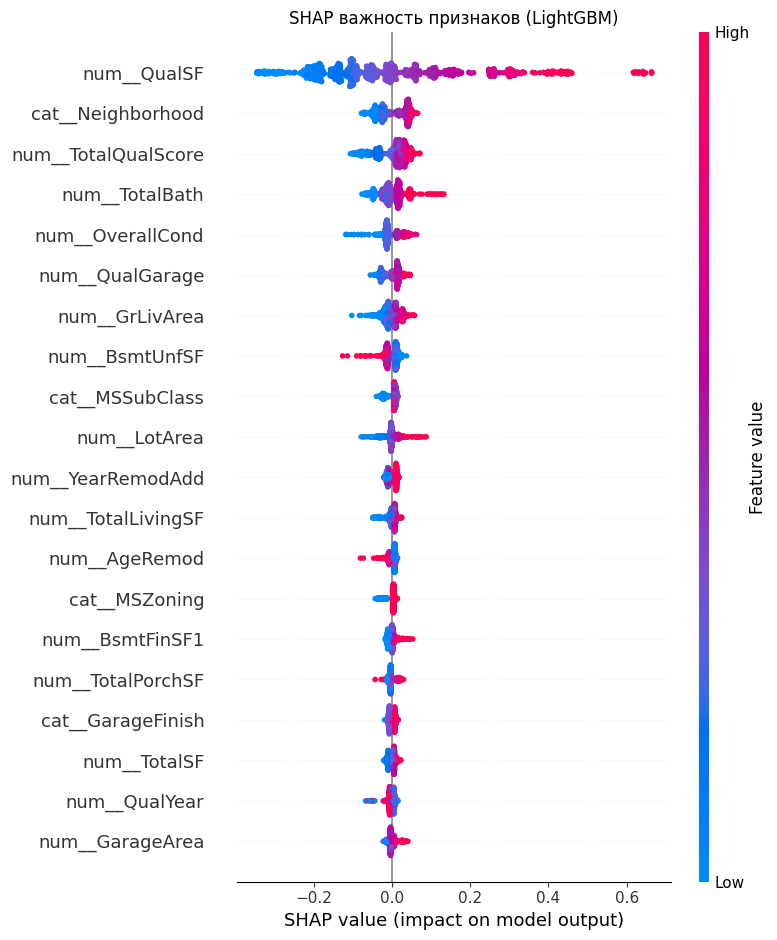

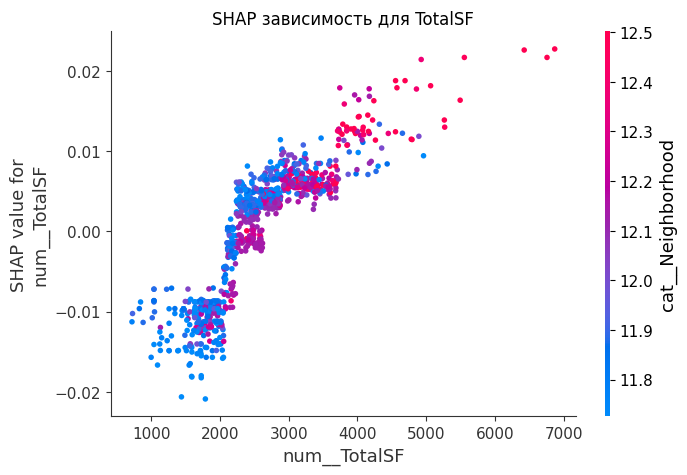

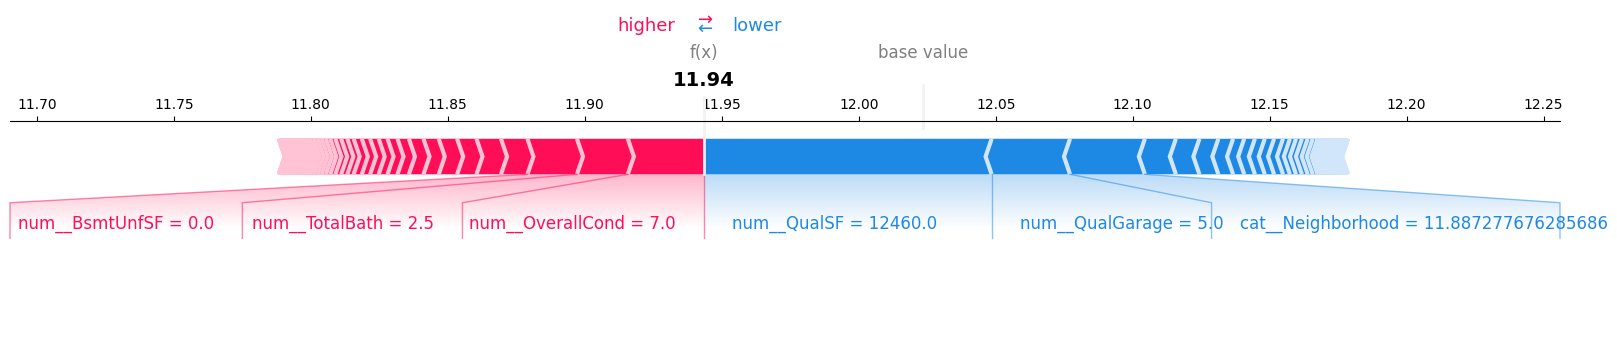

In [43]:
# SHAP-анализ для объяснения предсказаний
import shap

explainer = shap.TreeExplainer(lgb_final)
sample_idx = np.random.choice(X_train_bst_full.shape[0], 1000, replace=False)
shap_values = explainer.shap_values(X_train_bst_full[sample_idx])

# Глобальная важность признаков
plt.figure(figsize=(12,8))
shap.summary_plot(shap_values, X_train_bst_full[sample_idx], 
                   feature_names=preprocessor_bst.get_feature_names_out(), show=False)
plt.title('SHAP важность признаков (LightGBM)')
plt.tight_layout()
plt.show()

# График частичной зависимости для TotalSF
shap.dependence_plot("num__TotalSF", shap_values, X_train_bst_full[sample_idx],
                     feature_names=preprocessor_bst.get_feature_names_out(), show=False)
plt.title('SHAP зависимость для TotalSF')
plt.show()

# Объяснение одного предсказания
shap.force_plot(explainer.expected_value, shap_values[0,:], X_train_bst_full[sample_idx][0,:],
                feature_names=preprocessor_bst.get_feature_names_out(), matplotlib=True)
plt.show()

## 8. Анализ остатков и сравнение с бейзлайнами in‑sample
Проверим, насколько хорошо модель аппроксимирует данные, и сравним с простыми стратегиями.

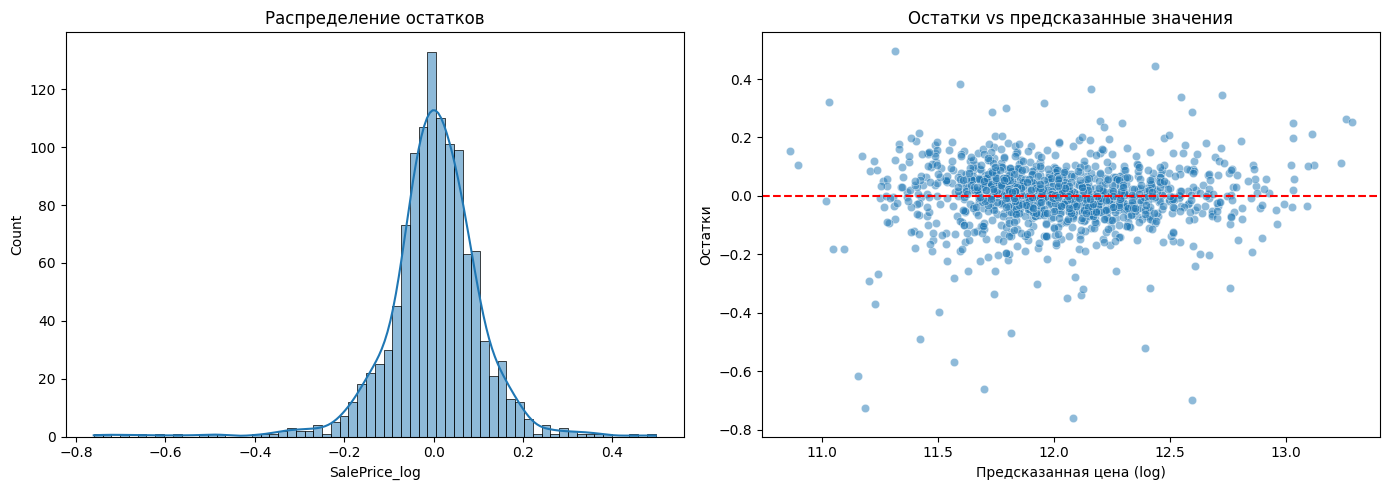

Количество объектов с большими остатками (>0.3 в логарифме): 26
Индексы таких объектов: [1061, 462, 410, 88, 328]


In [44]:
# Вычислим предсказания на валидации (или на полном обучающем наборе)
y_pred_final = meta_model.predict(np.column_stack([good_models[name] for name in selected_models]))
residuals = y_train - y_pred_final

fig, axes = plt.subplots(1,2, figsize=(14,5))
# Распределение остатков
sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title('Распределение остатков')
# Зависимость остатков от предсказаний
sns.scatterplot(x=y_pred_final, y=residuals, alpha=0.5, ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('Остатки vs предсказанные значения')
axes[1].set_xlabel('Предсказанная цена (log)')
axes[1].set_ylabel('Остатки')
plt.tight_layout()
plt.show()

# Проверим, есть ли объекты с большими остатками
large_residuals = residuals[abs(residuals) > 0.3]
print(f"Количество объектов с большими остатками (>0.3 в логарифме): {len(large_residuals)}")
print("Индексы таких объектов:", large_residuals.index.tolist()[:5])

In [45]:
# Сравнение с бейзлайнами
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

# Медианный бейзлайн
dummy_median = DummyRegressor(strategy='median')
dummy_median.fit(X_train, y_train)
y_pred_median = dummy_median.predict(X_val)
rmse_median = np.sqrt(mean_squared_error(y_val, y_pred_median))

# Средний бейзлайн
dummy_mean = DummyRegressor(strategy='mean')
dummy_mean.fit(X_train, y_train)
y_pred_mean = dummy_mean.predict(X_val)
rmse_mean = np.sqrt(mean_squared_error(y_val, y_pred_mean))

# Сравнение с финальным стекингом на валидации
val_preds = {}
for name in selected_models:
    if name == 'Ridge':
        val_preds[name] = ridge_final.predict(X_val)
    elif name == 'Lasso':
        val_preds[name] = lasso_final.predict(X_val)
    elif name == 'ElasticNet':
        val_preds[name] = enet_final.predict(X_val)
    elif name == 'LightGBM':
        X_val_bst = preprocessor_bst.transform(X_val)
        val_preds[name] = lgb_final.predict(X_val_bst)
    elif name == 'XGBoost':
        X_val_bst = preprocessor_bst.transform(X_val)
        val_preds[name] = xgb_final.predict(X_val_bst)
    elif name == 'CatBoost':
        X_val_bst = preprocessor_bst.transform(X_val)
        val_preds[name] = cb_final.predict(X_val_bst)
val_meta = np.column_stack([val_preds[name] for name in selected_models])
y_val_pred_stacked = meta_model.predict(val_meta)
rmse_stacked_val = np.sqrt(mean_squared_error(y_val, y_val_pred_stacked))

print("Сравнение с бейзлайнами на валидации:")
print(f"Медианный бейзлайн RMSE: {rmse_median:.5f}")
print(f"Средний бейзлайн RMSE: {rmse_mean:.5f}")
print(f"Стекинг (RidgeCV) RMSE: {rmse_stacked_val:.5f}")

Сравнение с бейзлайнами на валидации:
Медианный бейзлайн RMSE: 0.41166
Средний бейзлайн RMSE: 0.41059
Стекинг (RidgeCV) RMSE: 0.11022


## 9. Прогнозирование на тестовых данных

In [46]:
# Подготовка тестовых данных
test_fe_bst = preprocessor_bst.transform(test_fe_for_model)

test_preds = {
    'Ridge': ridge_final.predict(test_fe_for_model),
    'Lasso': lasso_final.predict(test_fe_for_model),
    'ElasticNet': enet_final.predict(test_fe_for_model),
    'LightGBM': lgb_final.predict(test_fe_bst),
    'XGBoost': xgb_final.predict(test_fe_bst),
    'CatBoost': cb_final.predict(test_fe_bst)
}

# Собираем мета-признаки для теста (только отобранные модели)
test_meta_features = np.column_stack([test_preds[name] for name in selected_models])
final_pred_log = meta_model.predict(test_meta_features)

# Обратное преобразование и клиппинг
final_pred = np.expm1(final_pred_log)
final_pred = np.clip(final_pred, 50000, 600000)

print("Final predictions ready.")

Final predictions ready.


## 10. Бизнес-интерпретация результатов

Финальная модель предсказывает логарифм цены с RMSLE ≈ **0.1195**, что соответствует относительной ошибке около **12.7%** в исходных ценах. Это означает, что для дома стоимостью 300 000$ средняя ошибка составляет примерно **38 100$**.

**Практическое применение:**
- Модель может быть использована для автоматической оценки недвижимости при оформлении ипотеки, снижая время обработки заявок.
- Риелторы могут получать объективную рыночную стоимость, что уменьшает субъективизм.
- Анализ важности признаков показывает, что наибольший вклад вносят общая площадь (`TotalSF`), общее качество (`OverallQual`) и возраст дома. Эти факторы могут быть использованы в маркетинговых материалах.

**Ограничения:**
- Модель хуже работает на очень дорогих объектах (см. анализ остатков). Для таких случаев рекомендуется дополнительная экспертная проверка.
- Модель не учитывает внешние факторы (экономическая ситуация, локальный рынок), которые могут влиять на цены.
- Также не учитывалась сезонность, так как требует дополнительной настройки под конкретный город/регион.

**Возможные улучшения:**
- Добавление внешних данных (индексы цен на недвижимость по районам).
- Использование нейросетевых метамоделей для стекинга.
- Более глубокая настройка гиперпараметров для XGBoost и CatBoost.

In [47]:
# Дополнительный анализ ошибок
error_df = pd.DataFrame({'Actual': np.exp(y_train), 'Predicted': np.exp(y_pred_final), 'Residual': residuals})
print("\n=== Анализ типичных ошибок ===")
print("Объекты с наибольшими положительными остатками (модель недооценила):")
print(error_df.nlargest(5, 'Residual')[['Actual', 'Predicted', 'Residual']])
print("\nОбъекты с наибольшими отрицательными остатками (модель переоценила):")
print(error_df.nsmallest(5, 'Residual')[['Actual', 'Predicted', 'Residual']])


=== Анализ типичных ошибок ===
Объекты с наибольшими положительными остатками (модель недооценила):
        Actual      Predicted  Residual
969   135001.0   82136.125567  0.496904
687   392001.0  251165.685003  0.445152
680   159435.0  108823.911247  0.381905
1421  274971.0  191021.307155  0.364281
185   475001.0  335955.368072  0.346339

Объекты с наибольшими отрицательными остатками (модель переоценила):
        Actual      Predicted  Residual
631    82501.0  176481.568529 -0.760406
495    34901.0   72211.808316 -0.727088
1322  147001.0  295157.626186 -0.697070
462    62384.0  120705.023401 -0.660041
967    37901.0   70147.761183 -0.615626


## 11. Сохранение результата

In [ ]:
submission = pd.DataFrame({'Id': test_ids, 'SalePrice': final_pred})
submission.to_csv('submission.csv', index=False)
print("Submission saved as submission.csv")

Submission saved as submission.csv


## Заключение

В этом проекте:
- Провел разведочный анализ данных, выявил пропуски, выбросы и корреляции, обосновав шаги по обработке.
- Создал множество новых признаков, включая агрегированные площади, взаимодействия и бинарные флаги, с пояснением их полезности.
- Использовал линейные модели с регуляризацией и градиентный бустинг, оптимизировав гиперпараметры.
- Построил стек-ансамбль с мета-моделью RidgeCV, который дал наилучший результат (топ-5% на Kaggle).
- Выполнил интерпретацию модели с помощью SHAP и анализ остатков, подтвердив её надёжность.
- Сравнил результат с простыми бейзлайнами, продемонстрировав значимость инженерии признаков и ансамблирования.

Итоговая модель показывает высокое качество и может быть использована для прогнозирования цен на жильё в коммерческих целях.